In [1]:
import wrds
import pandas as pd

# Step 1: Connect with WRDS.
db = wrds.Connection(wrds_username='jinglong')

Loading library list...
Done


In [2]:
# Step 2: Write SQL query statements.
sql_query = """
SELECT tic, fyear, revt, ni, at, lt
FROM comp.funda
WHERE tic IN ('KO', 'PEP')
    AND fyear >= 2015
    AND fyear <= 2025
    AND indfmt = 'INDL'
    AND datafmt = 'STD'
    AND popsrc = 'D'
    AND consol = 'C'
"""

# Step 3: Download and view data.
raw_data = db.raw_sql(sql_query)

print(raw_data.head())

  tic  fyear     revt      ni       at       lt
0  KO   2015  44294.0  7351.0  90093.0  64329.0
1  KO   2016  41863.0  6527.0  87270.0  64050.0
2  KO   2017  35410.0  1248.0  87896.0  68919.0
3  KO   2018  31856.0  6434.0  83216.0  64158.0
4  KO   2019  37266.0  8920.0  86381.0  65283.0


In [4]:
# Step 4: Data cleaning and metric calculation.
# 1. Copy the original data and exclude rows that may have missing values (NaN) to ensure computational security.
df = raw_data.dropna().copy()

# 2. Calculate profit margin = net profit / revenue * 100.
df['Profit_Margin(%)'] = (df['ni'] / df['revt']) * 100

# 3. Calculate leverage = total liabilities / total assets * 100.
df['Leverage(%)'] = (df['lt'] / df['at']) * 100

# 4. Keep two decimal places.
df['Profit_Margin(%)'] = df['Profit_Margin(%)'].round(2)
df['Leverage(%)'] = df['Leverage(%)'].round(2)

# Step 5: Use pivot table to contrast.
pm_pivot = df.pivot_table(index='tic', columns='fyear', values='Profit_Margin(%)')
lev_pivot = df.pivot_table(index='tic', columns='fyear', values='Leverage(%)')

# Print final contrast
print("=== Core profitability: (Profit Margin %) Contrast ===")
print(pm_pivot)
print("\n")
print("=== Financial health: (Leverage %) Contrast ===")
print(lev_pivot)

=== Core profitability: (Profit Margin %) Contrast ===
fyear  2015   2016  2017   2018   2019   2020   2021   2022   2023   2024  \
tic                                                                         
KO     16.6  15.59  3.52   20.2  23.94  23.47  25.28  22.19  23.42  22.59   
PEP    8.65  10.08  7.65  19.35  10.89  10.12   9.59  10.31   9.92  10.43   

fyear   2025  
tic           
KO     27.34  
PEP     8.77  


=== Financial health: (Leverage %) Contrast ===
fyear   2015   2016   2017   2018   2019   2020   2021   2022   2023   2024  \
tic                                                                           
KO      71.4  73.39  78.41   77.1  75.58  75.62  73.65  72.16  71.87  73.77   
PEP    82.73  84.89  86.24  81.19  81.07  85.42  82.52  81.26  81.45  81.73   

fyear   2025  
tic           
KO      67.3  
PEP    80.87  


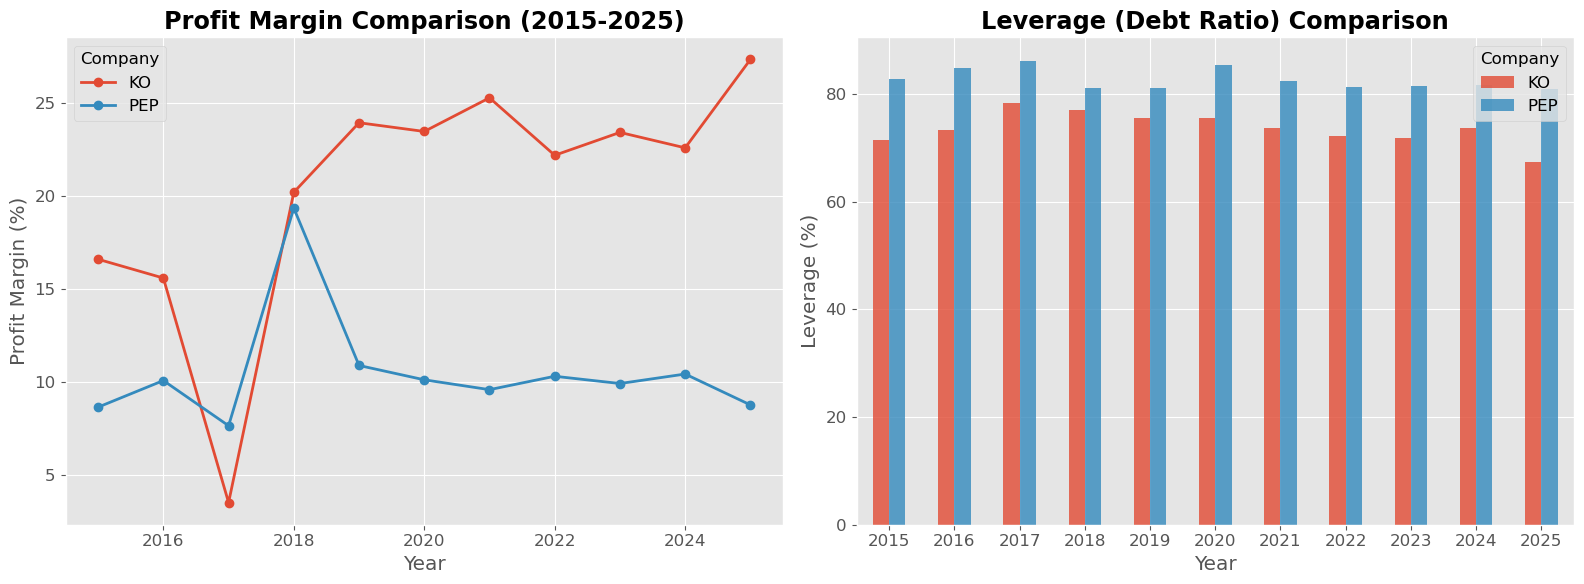

In [6]:
# Step 6: Data visualization.
import matplotlib.pyplot as plt

#
plt.style.use('ggplot')
plt.rcParams['font.size'] = 12

#
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# ---- Figure 1: Net profit margin comparision (line chart) ----
pm_pivot.T.plot(kind='line', marker='o', linewidth=2, ax=axes[0])
axes[0].set_title('Profit Margin Comparison (2015-2025)', fontweight='bold')
axes[0].set_ylabel('Profit Margin (%)')
axes[0].set_xlabel('Year')
axes[0].legend(title='Company')

# ---- Figure 2: Comparision of asset-liability ratio (bar chart) ----
lev_pivot.T.plot(kind='bar', ax=axes[1], alpha=0.8)
axes[1].set_title('Leverage (Debt Ratio) Comparison', fontweight='bold')
axes[1].set_ylabel('Leverage (%)')
axes[1].set_xlabel('Year')
axes[1].legend(title='Company')
# Ensure the years on the X-axis are displayed horizontally.
axes[1].tick_params(axis='x', rotation=0)

# Optimize layout for presentation.
plt.tight_layout()
plt.savefig('financial_comparision_ko_vs_pep.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [11]:
db.close()

AttributeError: 'NoneType' object has no attribute 'dispose'